## 1. Entendimiento del Negocio

En el Valle de Aburrá y el departamento de Antioquia, las Infecciones Respiratorias Agudas (IRA) representan un desafío crítico para la salud pública, frecuentemente exacerbado por factores ambientales como la mala calidad del aire y las variaciones climáticas. Actualmente, la gestión de estas enfermedades tiene un enfoque clínico y reactivo.El objetivo de VitalRisk AI es transformar este paradigma hacia un enfoque preventivo territorial. Se busca entender los patrones de notificación de eventos respiratorios en la población para correlacionarlos posteriormente con variables ambientales, permitiendo generar alertas tempranas y optimizar la toma de decisiones en salud pública.

## 2. Enfoque Analítico

Desarrollar un **análisis exploratorio (EDA)** de la base de datos histórica del SIVIGILA para **perfilar el comportamiento espaciotemporal de las ESI - IRA.** Este análisis preparará la variable objetivo (Target) que alimentará un modelo de regresión basado en ensambles de árboles, el cual busca predecir la tendencia de casos respiratorios.

**Metas específicas del EDA:**
- Limpiar, estandarizar y consolidar múltiples años de notificaciones (2018-2023).
- Agrupar los casos a un nivel de granularidad de Municipio y Semana Epidemiológica.
- Preparar los datos para lograr una métrica de éxito en el modelo predictivo final con un coeficiente de determinación **$R^2 > 0.65$** sobre el conjunto de validación.

## 3. Requerimientos de Datos

Para lograr el enfoque analítico, se requiere la extracción y procesamiento de los siguientes conjuntos de datos desde el portal de Datos Abiertos (INS / SIVIGILA):
- **Llave Temporal:** Fecha de inicio de síntomas y semana epidemiológica.
- **Llave Espacial:** Código territorial (DIVIPOLA / DANE) del municipio de ocurrencia.
- **Variable Clínica:** Códigos CIE-10 asociados a patologías respiratorias (ej. J00-J22, J44, J45).
- **Covariables Demográficas:** Edad y sexo del paciente.
- **Restricciones (Filtros):** Registros limitados temporalmente al periodo histórico 2018-2023, gestionando adecuadamente la anomalía estadística introducida por la pandemia (marzo 2020 - diciembre 2021).

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings

warnings.filterwarnings("ignore")


In [ ]:
# %pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import openpyxl


In [ ]:
#Cargando datos de ESI_IRA del 2018 y filtrandolos para el deparamento de Antioquia (COD_DPTO_O == 5)
ira18 = pd.read_excel('../data/raw/sivigila/Datos_2018_345.xlsx')
ira18 = ira18[ira18['COD_DPTO_O'] == 5]
ira18.info()

<class 'pandas.DataFrame'>
Index: 624 entries, 2 to 7175
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Partición                  624 non-null    str    
 1   CONSECUTIVE                624 non-null    int64  
 2   COD_EVE                    624 non-null    int64  
 3   FEC_NOT                    624 non-null    str    
 4   SEMANA                     624 non-null    int64  
 5   ANO                        624 non-null    int64  
 6   COD_PRE                    624 non-null    int64  
 7   COD_SUB                    624 non-null    int64  
 8   EDAD                       624 non-null    int64  
 9   UNI_MED                    624 non-null    int64  
 10  nacionalidad               624 non-null    str    
 11  nombre_nacionalidad        624 non-null    str    
 12  SEXO                       624 non-null    str    
 13  COD_PAIS_O                 624 non-null    int64  
 14  COD_DPTO_

In [ ]:
#Cargando datos de ESI_IRA del 2019 y filtrandolos para el deparamento de Antioquia (COD_DPTO_O == 5)
ira19 = pd.read_excel('../data/raw/sivigila/Datos_2019_345.xlsx')
ira19 = ira19[ira19['COD_DPTO_O'] == 5]
ira19.info()

<class 'pandas.DataFrame'>
Index: 673 entries, 11 to 6210
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Partición                  673 non-null    str    
 1   CONSECUTIVE                673 non-null    int64  
 2   COD_EVE                    673 non-null    int64  
 3   FEC_NOT                    673 non-null    str    
 4   SEMANA                     673 non-null    int64  
 5   ANO                        673 non-null    int64  
 6   COD_PRE                    673 non-null    int64  
 7   COD_SUB                    673 non-null    int64  
 8   EDAD                       673 non-null    int64  
 9   UNI_MED                    673 non-null    int64  
 10  nacionalidad               673 non-null    str    
 11  nombre_nacionalidad        673 non-null    str    
 12  SEXO                       673 non-null    str    
 13  COD_PAIS_O                 673 non-null    int64  
 14  COD_DPTO

In [ ]:
#Cargando datos de ESI_IRA del 2020 y filtrandolos para el deparamento de Antioquia (COD_DPTO_O == 5)
ira20 = pd.read_excel('../data/raw/sivigila/Datos_2020_345.xlsx')
ira20 = ira20[ira20['COD_DPTO_O'] == 5]
ira20.info()

<class 'pandas.DataFrame'>
Index: 770 entries, 47 to 8063
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Partición                  770 non-null    str    
 1   CONSECUTIVE                770 non-null    int64  
 2   COD_EVE                    770 non-null    int64  
 3   FEC_NOT                    770 non-null    str    
 4   SEMANA                     770 non-null    int64  
 5   ANO                        770 non-null    int64  
 6   COD_PRE                    770 non-null    int64  
 7   COD_SUB                    770 non-null    int64  
 8   EDAD                       770 non-null    int64  
 9   UNI_MED                    770 non-null    int64  
 10  nacionalidad               770 non-null    int64  
 11  nombre_nacionalidad        770 non-null    str    
 12  SEXO                       770 non-null    str    
 13  COD_PAIS_O                 770 non-null    int64  
 14  COD_DPTO

In [ ]:
#Cargando datos de ESI_IRA del 2021 y filtrandolos para el deparamento de Antioquia (COD_DPTO_O == 5)
ira21 = pd.read_excel('../data/raw/sivigila/Datos_2021_345.xlsx')
ira21 = ira21[ira21['COD_DPTO_O'] == 5]
ira21.info()

<class 'pandas.DataFrame'>
Index: 776 entries, 4 to 5045
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Partición                  776 non-null    str    
 1   CONSECUTIVE                776 non-null    int64  
 2   COD_EVE                    776 non-null    int64  
 3   FEC_NOT                    776 non-null    str    
 4   SEMANA                     776 non-null    int64  
 5   ANO                        776 non-null    int64  
 6   COD_PRE                    776 non-null    int64  
 7   COD_SUB                    776 non-null    int64  
 8   EDAD                       776 non-null    int64  
 9   UNI_MED                    776 non-null    int64  
 10  nacionalidad               776 non-null    int64  
 11  nombre_nacionalidad        776 non-null    str    
 12  SEXO                       776 non-null    str    
 13  COD_PAIS_O                 776 non-null    int64  
 14  COD_DPTO_

In [ ]:
#Cargando datos de ESI_IRA del 2022 y filtrandolos para el deparamento de Antioquia (COD_DPTO_O == 5)
ira22 = pd.read_excel('../data/raw/sivigila/Datos_2022_345.xlsx')
ira22 = ira22[ira22['COD_DPTO_O'] == 5]
ira22.info()

<class 'pandas.DataFrame'>
Index: 907 entries, 45 to 7995
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Partición                  907 non-null    str    
 1   CONSECUTIVE                907 non-null    int64  
 2   COD_EVE                    907 non-null    int64  
 3   FEC_NOT                    907 non-null    str    
 4   SEMANA                     907 non-null    int64  
 5   ANO                        907 non-null    int64  
 6   COD_PRE                    907 non-null    int64  
 7   COD_SUB                    907 non-null    int64  
 8   EDAD                       907 non-null    int64  
 9   UNI_MED                    907 non-null    int64  
 10  nacionalidad               907 non-null    int64  
 11  nombre_nacionalidad        907 non-null    str    
 12  SEXO                       907 non-null    str    
 13  COD_PAIS_O                 907 non-null    int64  
 14  COD_DPTO

In [ ]:
#Cargando datos de ESI_IRA del 2018 y filtrandolos para el deparamento de Antioquia (COD_DPTO_O == 5)
ira23 = pd.read_excel('../data/raw/sivigila/Datos_2023_345.xlsx')
ira23 = ira23[ira23['COD_DPTO_O'] == 5]
#Se presenta un error de la columna CONSECUTIVE_12, se renombra a CONSECUTIVE para mantener la consistencia con los otros años
ira23['CONSECUTIVE'] = ira23['CONSECUTIVE_12']
ira23.drop(columns=['CONSECUTIVE_12'], inplace=True)
ira23.info()

<class 'pandas.DataFrame'>
Index: 728 entries, 0 to 8296
Data columns (total 73 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   COD_EVE                    728 non-null    int64  
 1   FEC_NOT                    728 non-null    str    
 2   SEMANA                     728 non-null    int64  
 3   ANO                        728 non-null    int64  
 4   COD_PRE                    728 non-null    int64  
 5   COD_SUB                    728 non-null    int64  
 6   EDAD                       728 non-null    int64  
 7   UNI_MED                    728 non-null    int64  
 8   nacionalidad               728 non-null    int64  
 9   nombre_nacionalidad        728 non-null    str    
 10  SEXO                       728 non-null    str    
 11  COD_PAIS_O                 728 non-null    int64  
 12  COD_DPTO_O                 728 non-null    int64  
 13  COD_MUN_O                  728 non-null    int64  
 14  AREA     

In [ ]:
#Se agrupan todos los anyos en un solo dataframe para facilitar el análisis exploratorio
ira = pd.concat([ira18, ira19, ira20, ira21, ira22, ira23], ignore_index=True)
ira.info()

<class 'pandas.DataFrame'>
RangeIndex: 4478 entries, 0 to 4477
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Partición                  3750 non-null   str    
 1   CONSECUTIVE                4478 non-null   int64  
 2   COD_EVE                    4478 non-null   int64  
 3   FEC_NOT                    4478 non-null   str    
 4   SEMANA                     4478 non-null   int64  
 5   ANO                        4478 non-null   int64  
 6   COD_PRE                    4478 non-null   int64  
 7   COD_SUB                    4478 non-null   int64  
 8   EDAD                       4478 non-null   int64  
 9   UNI_MED                    4478 non-null   int64  
 10  nacionalidad               4478 non-null   object 
 11  nombre_nacionalidad        4478 non-null   str    
 12  SEXO                       4478 non-null   str    
 13  COD_PAIS_O                 4478 non-null   int64  
 14  COD

In [25]:
ira.columns

Index(['Partición', 'CONSECUTIVE', 'COD_EVE', 'FEC_NOT', 'SEMANA', 'ANO',
       'COD_PRE', 'COD_SUB', 'EDAD', 'UNI_MED', 'nacionalidad',
       'nombre_nacionalidad', 'SEXO', 'COD_PAIS_O', 'COD_DPTO_O', 'COD_MUN_O',
       'AREA', 'OCUPACION', 'TIP_SS', 'COD_ASE', 'PER_ETN', 'GRU_POB',
       'nom_grupo', 'estrato', 'GP_DISCAPA', 'GP_DESPLAZ', 'GP_MIGRANT',
       'GP_CARCELA', 'GP_GESTAN', 'sem_ges', 'GP_INDIGEN', 'GP_POBICFB',
       'GP_MAD_COM', 'GP_DESMOVI', 'GP_PSIQUIA', 'GP_VIC_VIO', 'GP_OTROS',
       'fuente', 'COD_PAIS_R', 'COD_DPTO_R', 'COD_MUN_R', 'COD_DPTO_N',
       'COD_MUN_N', 'FEC_CON', 'INI_SIN', 'TIP_CAS', 'PAC_HOS', 'FEC_HOS',
       'CON_FIN', 'FEC_DEF', 'AJUSTE', 'FECHA_NTO', 'CER_DEF', 'CBMTE',
       'FEC_ARC_XL', 'FEC_AJU', 'FM_FUERZA', 'FM_UNIDAD', 'FM_GRADO',
       'confirmados', 'consecutive_origen', 'va_sispro',
       'Estado_final_de_caso', 'nom_est_f_caso', 'Nom_upgd', 'Pais_ocurrencia',
       'Nombre_evento', 'Departamento_ocurrencia', 'Municipio_ocu

## 4. Recoleccion de datos
- COD_EVE: es el codigo de evento sivigila que asegura que todos los eventos sean 345
- FEC_NOT: Fecha en la que se notifico del sintoma
- SEMANA: Semana en la que se notifico el sintoma
- ANO: Anyo en el que se notifico el sintoma
- EDAD: Edad que tiene el paciente al momento de presentar el sintoma
- UNI_MED: Unidad de medida de la edad (1=anyos, 2=meses, 3=dias)
- SEXO: sexo del paciente (H, M)
- COD_DPTO_O: codigo del departamento de ocurrencia del evento
- COD_MUN_O: codigo del municipio de ocurrencia del evento
- TIP_SS: tipo de seguridad social (C, I, N, P, S)
- INI_SIN: fecha en que iniciaron los sintomas
- confirmados: si el paciente fue confirmado como portador del sintoma
- nom_est_f_caso: la conclusion del paciente si es portador del sintoma

In [27]:
columnas_ira = ['COD_EVE','FEC_NOT','SEMANA','ANO','EDAD','UNI_MED','SEXO','COD_DPTO_O','COD_MUN_O','TIP_SS','INI_SIN','confirmados', 'nom_est_f_caso']
iraR = ira[columnas_ira]
iraR.info()

<class 'pandas.DataFrame'>
RangeIndex: 4478 entries, 0 to 4477
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   COD_EVE         4478 non-null   int64
 1   FEC_NOT         4478 non-null   str  
 2   SEMANA          4478 non-null   int64
 3   ANO             4478 non-null   int64
 4   EDAD            4478 non-null   int64
 5   UNI_MED         4478 non-null   int64
 6   SEXO            4478 non-null   str  
 7   COD_DPTO_O      4478 non-null   int64
 8   COD_MUN_O       4478 non-null   int64
 9   TIP_SS          4478 non-null   str  
 10  INI_SIN         4478 non-null   str  
 11  confirmados     4478 non-null   int64
 12  nom_est_f_caso  4478 non-null   str  
dtypes: int64(8), str(5)
memory usage: 638.2 KB


# 5. Entendimiento de los Datos
- Analisis de Completitud
- Analisis Univariado
- Analisis Bivariado
- Analisis Multivariado
- balanceo de y (Si aplica)

In [28]:
import missingno as msno
import plotly.express as px

<Axes: >

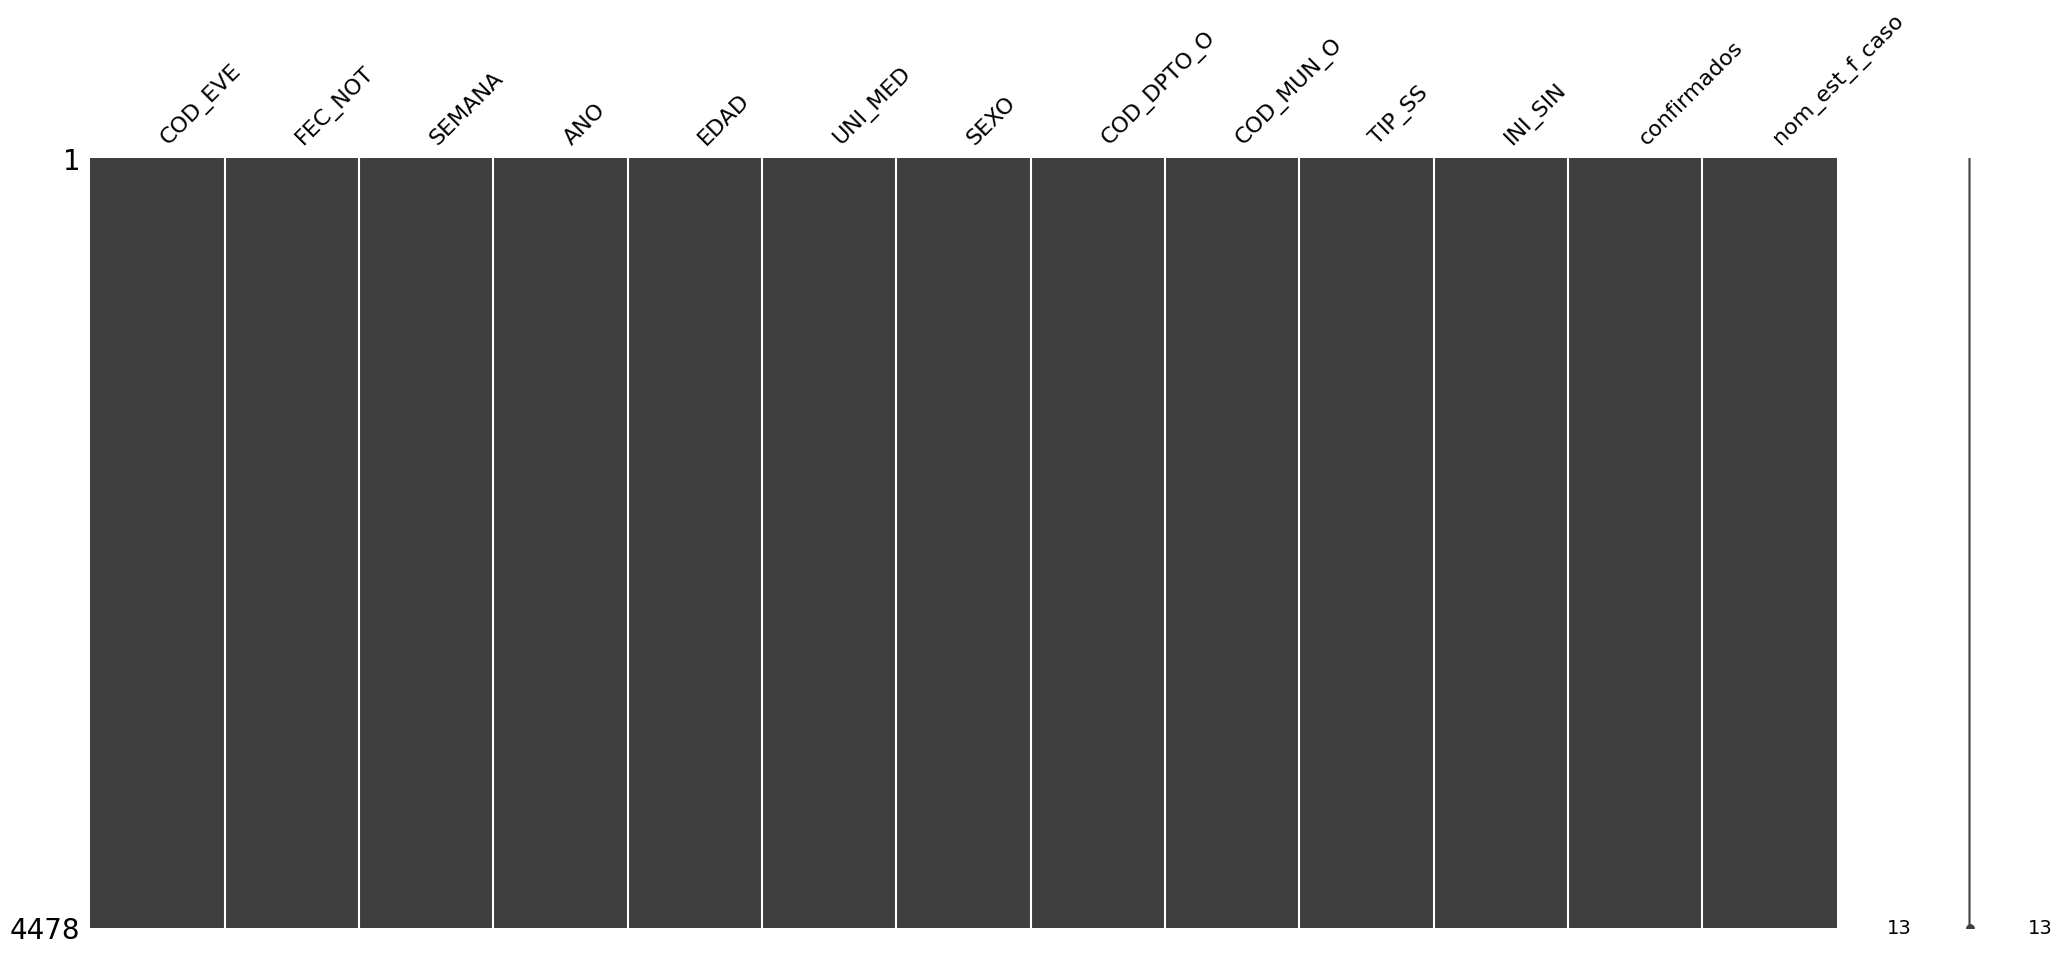

In [ ]:
# visualizacion de los datos faltantes por columnas para un individuo
msno.matrix(iraR)

<Axes: >

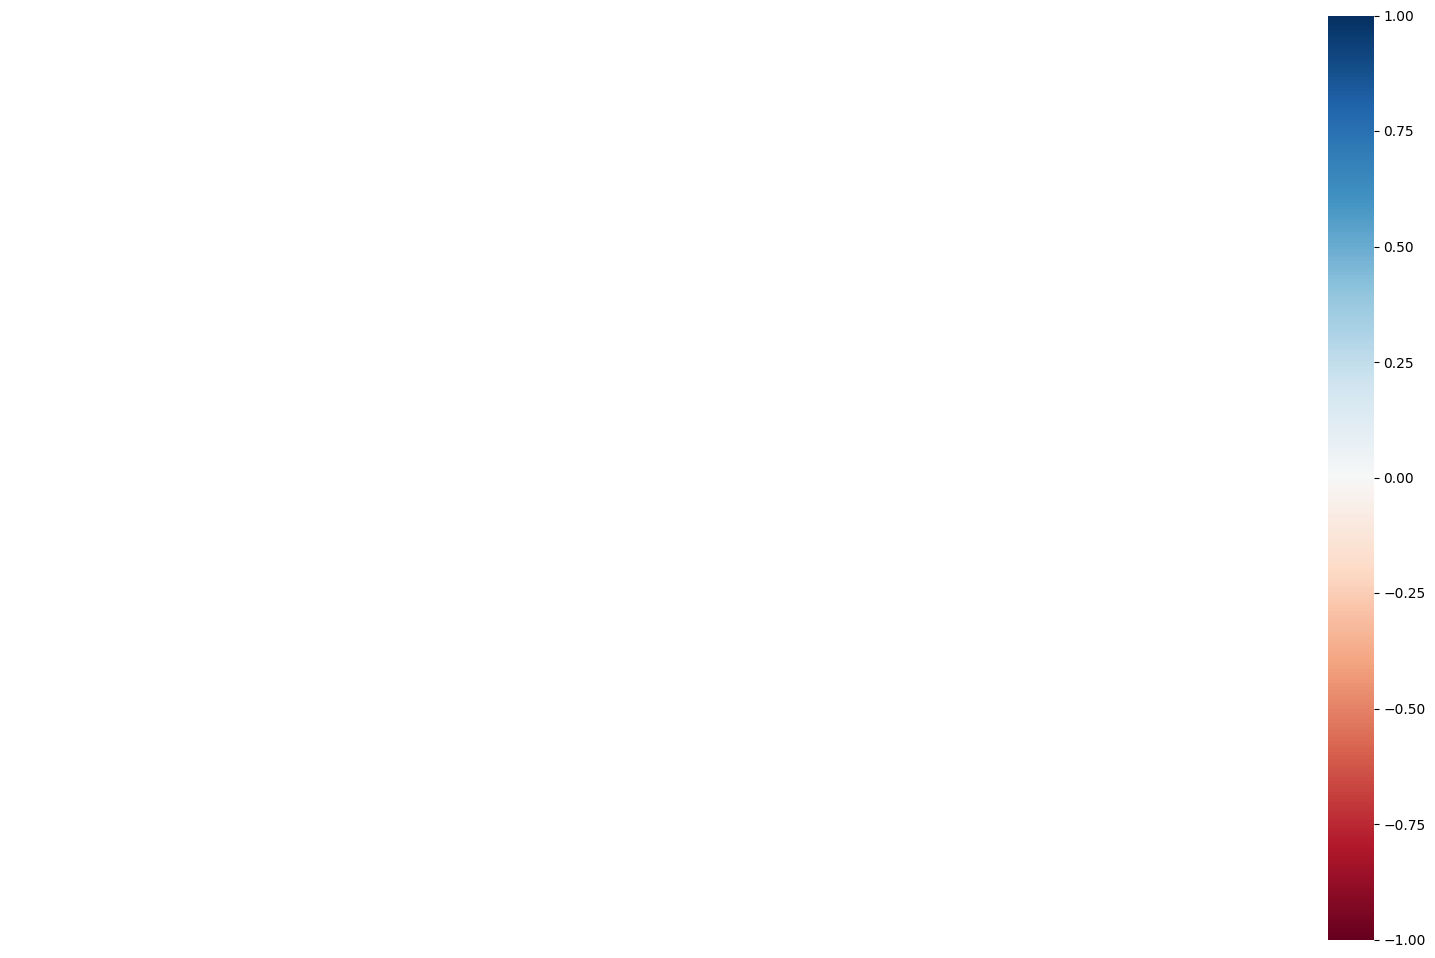

In [30]:
msno.heatmap(iraR)

<Axes: >

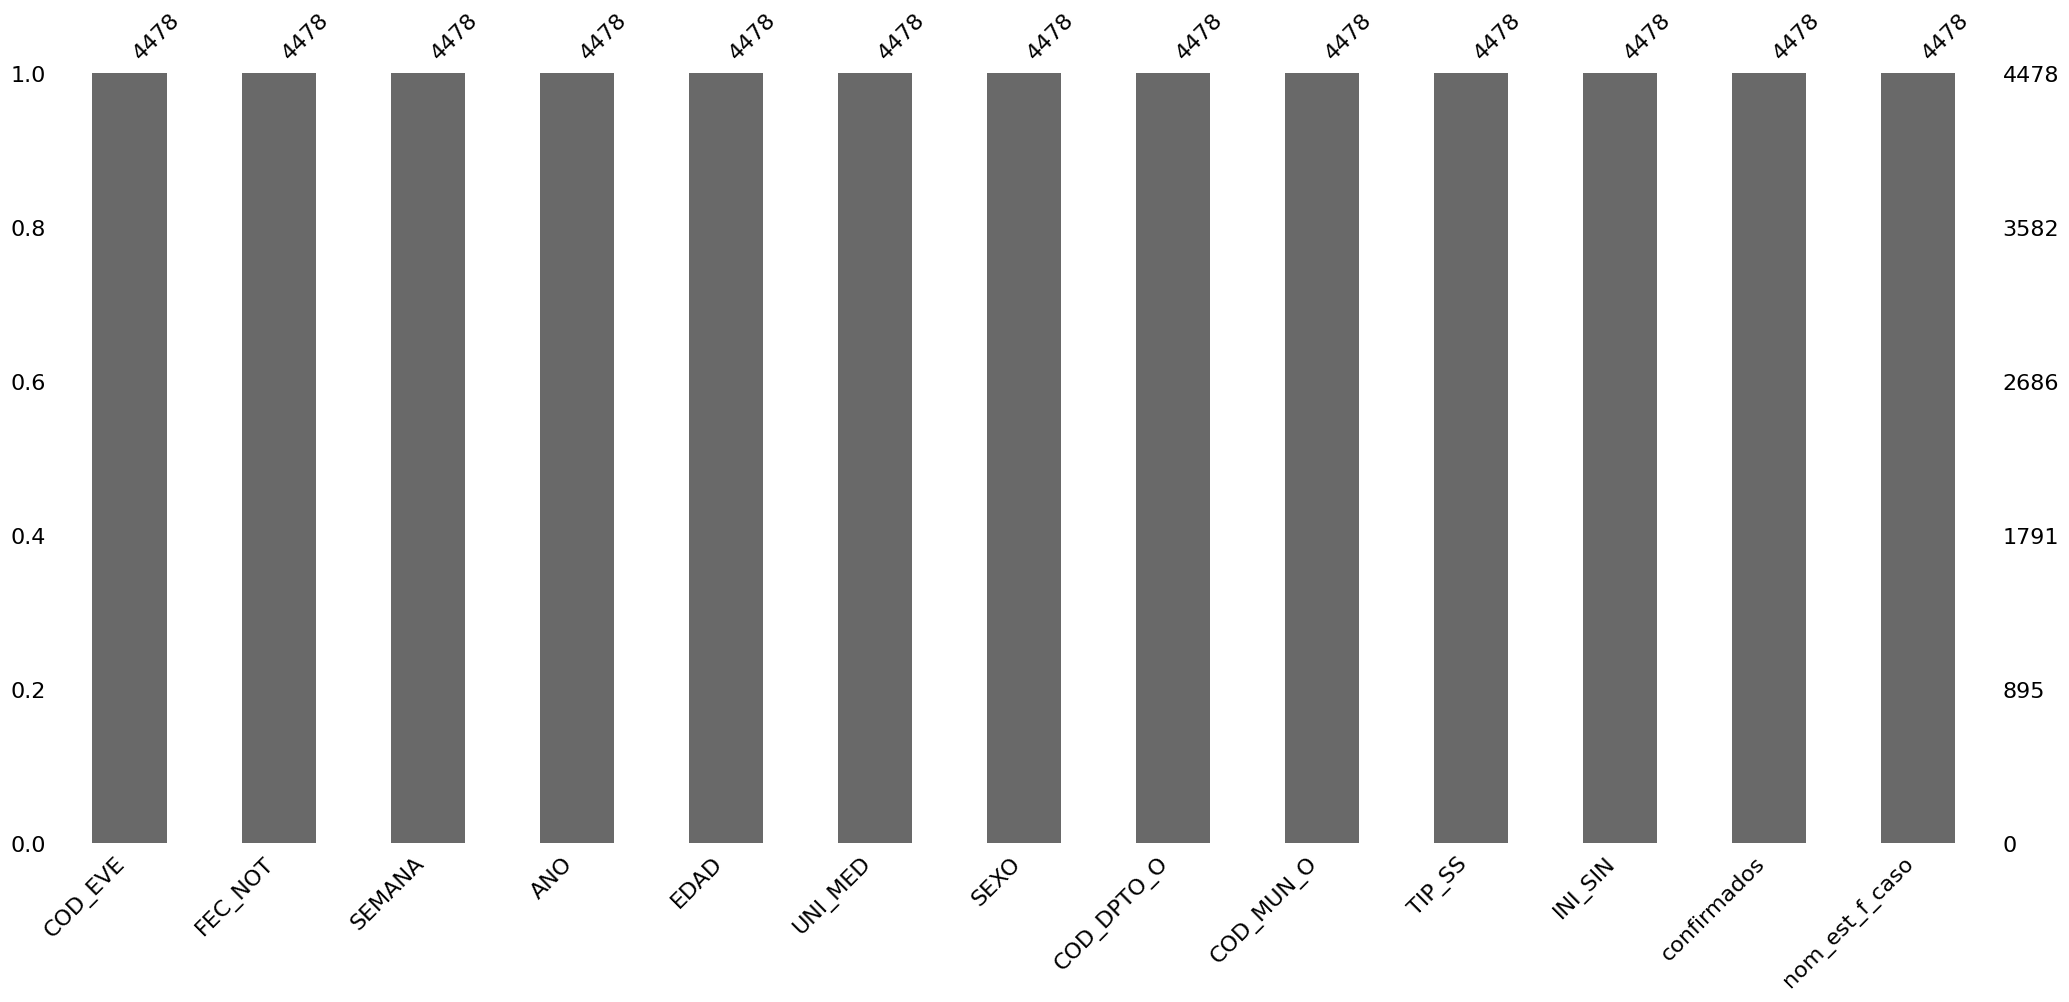

In [31]:
msno.bar(iraR)

In [33]:
iraR.isnull().sum()

COD_EVE           0
FEC_NOT           0
SEMANA            0
ANO               0
EDAD              0
UNI_MED           0
SEXO              0
COD_DPTO_O        0
COD_MUN_O         0
TIP_SS            0
INI_SIN           0
confirmados       0
nom_est_f_caso    0
dtype: int64

Verificamos que los datos que seleccionamos no presentan eventos de nulidad, por lo que procedemos con el entendimiento de los datos de forma univariada

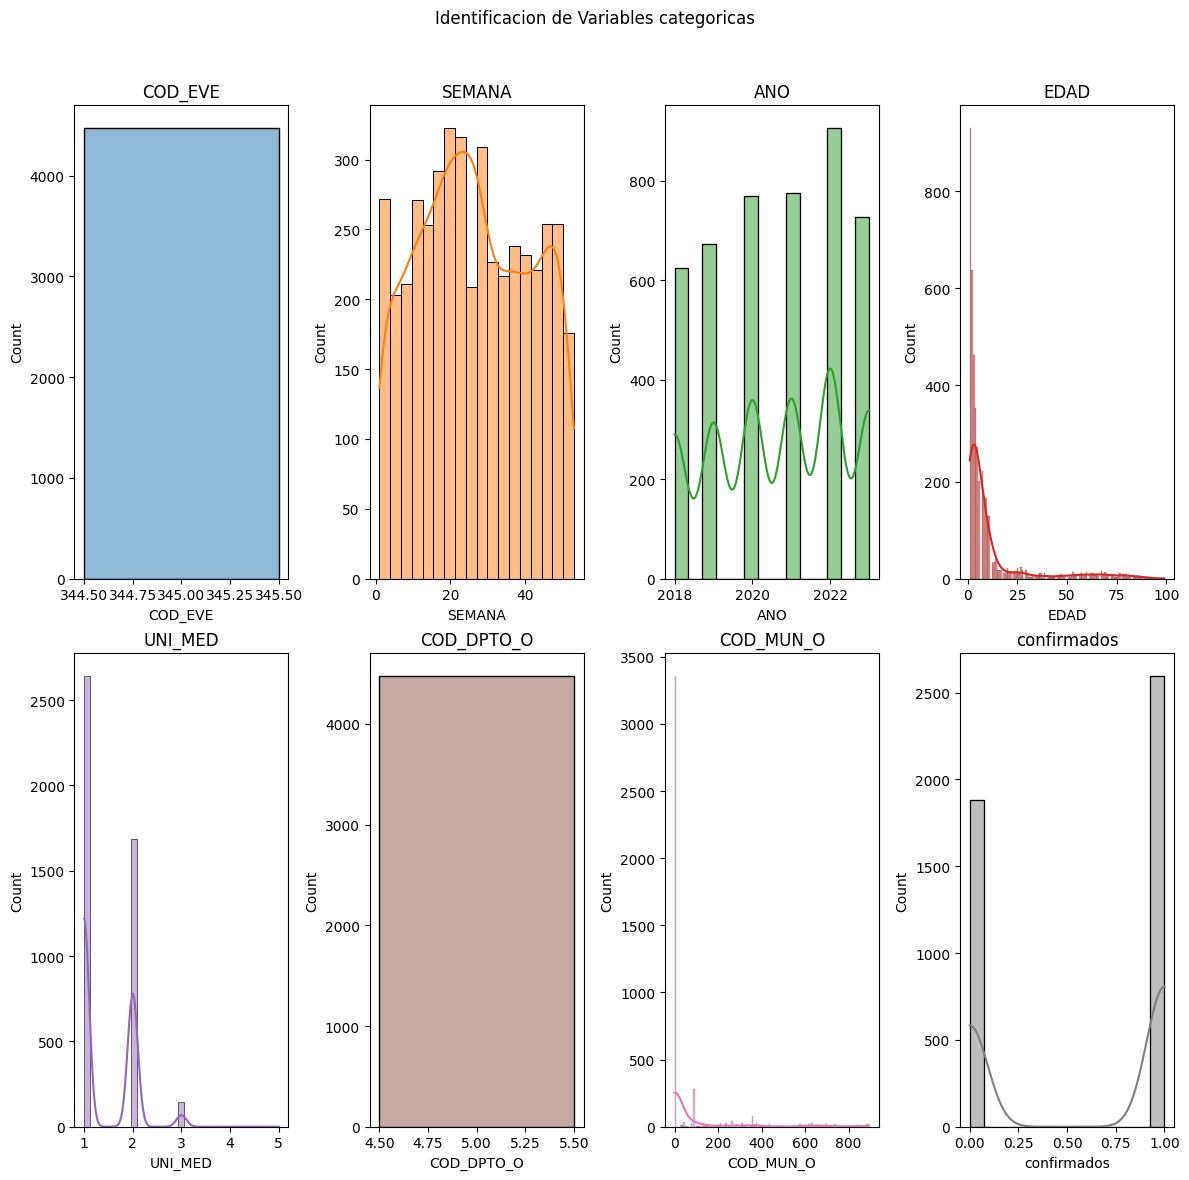

In [36]:
# Grafico de Histogramas de Frecuencia
fig, ax = plt.subplots(2,4, figsize=(12,12))
ax=ax.flat
num_col= iraR.select_dtypes(include = ['int64','float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data=iraR,x=col, kde=True,
                 color=(list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'],
                 ax=ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Identificacion de Variables categoricas')
plt.show()

Basado en los datos inicialmente numericos se ignora el codigo del evento, el cod_dpto_o y el cod_mun_o, pues son valores de identificacion: llaves.

Los datos que transmiten informacion son: semana, anyo, edad, uni_med y confirmados
- Semana presenta un fuerte peso en las semanas que nacionalmente se consideran de vacaciones, deberia realizarse un filtro de cada 4 semanas para lograr identificar con mas eficiencia los meses puntuales en los que se presentan picos de IRA
- Respecto al anyo, el sistema presenta una tendencia levemente al alza que o puede ser reflejada por consecuencia de la pandemia, un aumento de la natalidad para estos anyos(revisar analisis de edad) o una resistencia a los farmacos por parte de la ciudadania
- sobre la edad, se observa una cola pesada hacia la derecha, lo que indica una concentracion sobre que la mayoria de casos de ESI-IRAG se presentan en la infancia